# P2.1.1.8: Further ML Evaluation 
Step 2: Recreate in a notebook 

This is a notebook, I'm using to test/recreate exisiting evaluation scripts from the ClimSim code to get to work with my pipeline.

## Setup and collecting data/model

In [2]:
import torch
import models
import os
from omegaconf import OmegaConf
from hydra import initialize, initialize_config_module, initialize_config_dir, compose
import data_preparation
import logging 
import xarray as xr
import numpy as np



First we need to initilise the setup such that its realistic of the true pipeline scenario. To do this we:
1. Run a `qt` of `train_multi_seed.py` to get:
    - (optimised) model params 
    - multiple instances of the trained model through different seeds 
    This can be done by running the command:
    ```
    uv run train/train_multi_seed.py -m testing=qt model=yus_mlp
    ```
    And then find the path to the corresponding log folder

2. Load in the model(s) and therefore also the config setup

3. Collect prediction and target data 

In [3]:
path_to_model_folder = '/home/users/bradlesc/projects/ClimSim/logs/p2.1.1/9/testing/quick_test/2025-12-02-11-20-42/yus_mlp_group_False' 
target_seed = 0
model_checkpoint_path = os.path.join(path_to_model_folder, f'yus_mlp_{target_seed}_2025-12-02-11-20-42.ckpt')
model_params_path = os.path.join(path_to_model_folder, f'run_config_{target_seed}.yaml')
 

In [4]:
initialize(version_base=None, config_path="../config")
cfg = compose(config_name="train_general.yaml")
print(cfg.dataset)


{'dataset_name': 'climsim_from_raw', 'input_dim': 124, 'output_dim': 128, 'levels': 60, 'base_folder_path': '/gws/nopw/j04/iecdt/bstanleyclamp/ClimSim_lowres/train/', 'path_to_grid_info': '/home/users/bradlesc/projects/ClimSim/grid_info/ClimSim_low-res_grid-info.nc', 'output_scale_file_path': '/home/users/bradlesc/projects/ClimSim/preprocessing/normalizations/outputs/output_scale.nc', 'target_years': ['0001', '0002', '0003'], 'target_months': ['02'], 'v1_inputs': ['state_t', 'state_q0001', 'state_ps', 'pbuf_SOLIN', 'pbuf_LHFLX', 'pbuf_SHFLX'], 'v1_targets': ['ptend_t', 'ptend_q0001', 'cam_out_NETSW', 'cam_out_FLWDS', 'cam_out_PRECSC', 'cam_out_PRECC', 'cam_out_SOLS', 'cam_out_SOLL', 'cam_out_SOLSD', 'cam_out_SOLLD'], 'dataset_testing_sample_rates': {'unit_test': 1, 'quick': 1000, 'reduced': 100, 'full': 7}, 'group_method': 'group_by_months', 'group_by_months': {'num_groups': 3, 'target_group': '${target_group}', 'groups': [['12', '01', '02'], ['03', '04', '05'], ['06', '07', '08']], 't

In [5]:
cfg.dataset.input_dim = 109
cfg.dataset.output_dim = 113
model_params = OmegaConf.load(model_params_path)
model = models.load_model_from_checkpoint(model_checkpoint_path, model_name='yus_mlp', model_params=model_params, data_params=cfg.dataset)

In [6]:
trainset = data_preparation.get_dataset(cfg.dataset, 'train', 'quick', 'yus_mlp')
testset = data_preparation.get_dataset(cfg.dataset, 'test', 'quick', 'yus_mlp', trainset.normalisation_stats)

In [7]:
print(trainset.normalised_target_ds)

<xarray.Dataset> Size: 4MB
Dimensions:         (sample: 18, lev: 60, ncol: 192)
Dimensions without coordinates: sample, lev, ncol
Data variables:
    ptend_t         (sample, lev, ncol) float64 2MB dask.array<chunksize=(1, 60, 192), meta=np.ndarray>
    ptend_q0001     (sample, lev, ncol) float64 2MB dask.array<chunksize=(1, 60, 192), meta=np.ndarray>
    cam_out_NETSW   (sample, ncol) float64 28kB dask.array<chunksize=(1, 192), meta=np.ndarray>
    cam_out_FLWDS   (sample, ncol) float64 28kB dask.array<chunksize=(1, 192), meta=np.ndarray>
    cam_out_PRECSC  (sample, ncol) float64 28kB dask.array<chunksize=(1, 192), meta=np.ndarray>
    cam_out_PRECC   (sample, ncol) float64 28kB dask.array<chunksize=(1, 192), meta=np.ndarray>
    cam_out_SOLS    (sample, ncol) float64 28kB dask.array<chunksize=(1, 192), meta=np.ndarray>
    cam_out_SOLL    (sample, ncol) float64 28kB dask.array<chunksize=(1, 192), meta=np.ndarray>
    cam_out_SOLSD   (sample, ncol) float64 28kB dask.array<chunksize=(

In [8]:
testloader = torch.utils.data.DataLoader(testset, batch_size=len(testset), shuffle=False)

preds = []
targets = []

model.eval()
with torch.no_grad():
    for batch in testloader:
        inputs, target = batch
        print("Input shape:", inputs.shape)
        print("Target shape:", target.shape)
        output = model(inputs)
        preds.append(output)
        targets.append(target)
preds = torch.cat(preds, dim=0)
targets = torch.cat(targets, dim=0)

print("Predictions shape:", preds.shape)
print("Targets shape:", targets.shape)


Input shape: torch.Size([3840, 109])
Target shape: torch.Size([3840, 113])
Predictions shape: torch.Size([3840, 113])
Targets shape: torch.Size([3840, 113])


Wow, that took a while longer than expected - now we move onto to the first step:

## Re weighting outputs 

### Reshape back into individual components

This is hardcoded for each of the individual variables, I will do the same

In [8]:
num_samples = preds.shape[0]
num_latlon = testset.num_latlon
max_t_level_index = 45
min_sh_level_index = 60
max_sh_level_index = min_sh_level_index + 60 - cfg.dataset.remove_high_altitude_specific_humidity_levels

In [9]:
ptend_t = output[:,:max_t_level_index].reshape((int(num_samples/num_latlon), num_latlon, max_t_level_index))
ptend_q0001 = output[:,min_sh_level_index:max_sh_level_index].reshape((int(num_samples/num_latlon), num_latlon, max_sh_level_index - min_sh_level_index))
netsw = output[:,max_sh_level_index].reshape((int(num_samples/num_latlon), num_latlon))
flwds = output[:,max_sh_level_index+1].reshape((int(num_samples/num_latlon), num_latlon))
precsc = output[:,max_sh_level_index+2].reshape((int(num_samples/num_latlon), num_latlon))
precc = output[:,max_sh_level_index+3].reshape((int(num_samples/num_latlon), num_latlon))
sols = output[:,max_sh_level_index+4].reshape((int(num_samples/num_latlon), num_latlon))
soll = output[:,max_sh_level_index+5].reshape((int(num_samples/num_latlon), num_latlon))
solsd = output[:,max_sh_level_index+6].reshape((int(num_samples/num_latlon), num_latlon))
solld = output[:,max_sh_level_index+7].reshape((int(num_samples/num_latlon), num_latlon))

print (f"ptend_t shape: {ptend_t.shape}")
print(f"netsw shape: {netsw.shape}")

ptend_t shape: torch.Size([20, 192, 45])
netsw shape: torch.Size([20, 192])


I am going to try and first convert into an xarray as I think this could help

In [10]:
ds = xr.Dataset(
    data_vars={
        "ptend_t": (("sample", "ncol", "lev"), ptend_t),
        "ptend_q0001": (("sample", "ncol", "lev"), ptend_q0001),
        "netsw": (("sample", "ncol"), netsw),
        "flwds": (("sample", "ncol"), flwds),
        "precsc": (("sample", "ncol"), precsc),
        "precc": (("sample", "ncol"), precc),
        "sols": (("sample", "ncol"), sols),
        "soll": (("sample", "ncol"), soll),
        "solsd": (("sample", "ncol"), solsd),
        "solld": (("sample", "ncol"), solld),
    },
    coords={
        "sample": range(ptend_t.shape[0]),
        "ncol": range(num_latlon),
        "lev": range(ptend_t.shape[2]),
    },
    attrs={
        "description": "Model predictions from YUS MLP model",
        "model_checkpoint": model_checkpoint_path,
    }
)

In [11]:
ds

<xarray.Dataset> Size: 2MB
Dimensions:      (sample: 20, ncol: 192, lev: 45)
Coordinates:
  * sample       (sample) int64 160B 0 1 2 3 4 5 6 7 ... 12 13 14 15 16 17 18 19
  * ncol         (ncol) int64 2kB 0 1 2 3 4 5 6 ... 185 186 187 188 189 190 191
  * lev          (lev) int64 360B 0 1 2 3 4 5 6 7 8 ... 37 38 39 40 41 42 43 44
Data variables:
    ptend_t      (sample, ncol, lev) float32 691kB 0.03208 -0.04119 ... -0.07639
    ptend_q0001  (sample, ncol, lev) float32 691kB 0.05554 0.04679 ... 0.08323
    netsw        (sample, ncol) float32 15kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    flwds        (sample, ncol) float32 15kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    precsc       (sample, ncol) float32 15kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    precc        (sample, ncol) float32 15kB 0.04227 0.04229 ... 0.04309 0.04303
    sols         (sample, ncol) float32 15kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    soll         (sample, ncol) float32 15kB 0.07724 0.07743 ... 0.07824 0.07774
    solsd        (sample, ncol) float32 15kB 0.02681 0.02669 ... 0.02695 0.02696
    solld        (sample, ncol) float32 15kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    description:       Model predictions from YUS MLP model
    model_checkpoint:  /home/users/bradlesc/projects/ClimSim/logs/p2.1.1/9/te...

## Undo output scaling

In [25]:
out_scale = xr.open_dataset(cfg.dataset.output_scale_file_path)
# print(out_scale)
out_scale = out_scale[list(cfg.dataset.v1_targets)]

out_scale = out_scale.isel(lev=slice(0, max_t_level_index))
out_scale

<xarray.Dataset> Size: 784B
Dimensions:         (lev: 45)
Dimensions without coordinates: lev
Data variables:
    ptend_t         (lev) float64 360B ...
    ptend_q0001     (lev) float64 360B ...
    cam_out_NETSW   float64 8B ...
    cam_out_FLWDS   float64 8B ...
    cam_out_PRECSC  float64 8B ...
    cam_out_PRECC   float64 8B ...
    cam_out_SOLS    float64 8B ...
    cam_out_SOLL    float64 8B ...
    cam_out_SOLSD   float64 8B ...
    cam_out_SOLLD   float64 8B ...

In [26]:
prefix = "cam_out_"

# Build a rename mapping for only the vars that start with "cam_out_"
rename_dict = {
    var: var[len(prefix):].lower()
    for var in out_scale.data_vars
    if var.startswith(prefix)
}

# Apply the rename
out_scale = out_scale.rename(rename_dict)
out_scale

<xarray.Dataset> Size: 784B
Dimensions:      (lev: 45)
Dimensions without coordinates: lev
Data variables:
    ptend_t      (lev) float64 360B ...
    ptend_q0001  (lev) float64 360B ...
    netsw        float64 8B ...
    flwds        float64 8B ...
    precsc       float64 8B ...
    precc        float64 8B ...
    sols         float64 8B ...
    soll         float64 8B ...
    solsd        float64 8B ...
    solld        float64 8B ...

In [19]:
ds

<xarray.Dataset> Size: 2MB
Dimensions:      (sample: 20, ncol: 192, lev: 45)
Coordinates:
  * sample       (sample) int64 160B 0 1 2 3 4 5 6 7 ... 12 13 14 15 16 17 18 19
  * ncol         (ncol) int64 2kB 0 1 2 3 4 5 6 ... 185 186 187 188 189 190 191
  * lev          (lev) int64 360B 0 1 2 3 4 5 6 7 8 ... 37 38 39 40 41 42 43 44
Data variables:
    ptend_t      (sample, ncol, lev) float32 691kB 0.03208 -0.04119 ... -0.07639
    ptend_q0001  (sample, ncol, lev) float32 691kB 0.05554 0.04679 ... 0.08323
    netsw        (sample, ncol) float32 15kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    flwds        (sample, ncol) float32 15kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    precsc       (sample, ncol) float32 15kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    precc        (sample, ncol) float32 15kB 0.04227 0.04229 ... 0.04309 0.04303
    sols         (sample, ncol) float32 15kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    soll         (sample, ncol) float32 15kB 0.07724 0.07743 ... 0.07824 0.07774
    solsd        (sample, ncol) float32 15kB 0.02681 0.02669 ... 0.02695 0.02696
    solld        (sample, ncol) float32 15kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    description:       Model predictions from YUS MLP model
    model_checkpoint:  /home/users/bradlesc/projects/ClimSim/logs/p2.1.1/9/te...

In [27]:
unscaled_ds = ds / out_scale
unscaled_ds

<xarray.Dataset> Size: 3MB
Dimensions:      (sample: 20, ncol: 192, lev: 45)
Coordinates:
  * sample       (sample) int64 160B 0 1 2 3 4 5 6 7 ... 12 13 14 15 16 17 18 19
  * ncol         (ncol) int64 2kB 0 1 2 3 4 5 6 ... 185 186 187 188 189 190 191
  * lev          (lev) int64 360B 0 1 2 3 4 5 6 7 8 ... 37 38 39 40 41 42 43 44
Data variables:
    ptend_t      (sample, ncol, lev) float64 1MB 3.193e-05 ... -7.603e-05
    ptend_q0001  (sample, ncol, lev) float64 1MB 1.959e-08 ... 2.936e-08
    netsw        (sample, ncol) float64 31kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    flwds        (sample, ncol) float64 31kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    precsc       (sample, ncol) float64 31kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    precc        (sample, ncol) float64 31kB 3.219e-08 3.22e-08 ... 3.277e-08
    sols         (sample, ncol) float64 31kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    soll         (sample, ncol) float64 31kB 16.79 16.83 16.79 ... 17.01 16.9
    solsd        (sample, ncol) float64 31kB 4.396 4.376 4.386 ... 4.418 4.42
    solld        (sample, ncol) float64 31kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

In [28]:
print(ds['ptend_t'][0,0, 5].values)
print(out_scale['ptend_t'][5].values)
print(unscaled_ds['ptend_t'][0,0, 5].values)

-0.034742534
1004.64
-3.458207334031495e-05


## Weight vertical levels by dp/g

This is a more complicated one, but its good for me to reproduce it so I have a better understanding of what its doing:

1. We need to set the pressure grid 
2. We need to get g
3. *simply* just var * dp/g

so dp could mean differential pressure, which does look like what its doing 

In [29]:
# Load in grid info
grid_info = xr.open_dataset(cfg.dataset.path_to_grid_info)

In [30]:
trainset.normalisation_stats

{'mean': <xarray.Dataset> Size: 992B
 Dimensions:      (lev: 60)
 Dimensions without coordinates: lev
 Data variables:
     state_t      (lev) float64 480B dask.array<chunksize=(60,), meta=np.ndarray>
     state_q0001  (lev) float64 480B dask.array<chunksize=(60,), meta=np.ndarray>
     state_ps     float64 8B dask.array<chunksize=(), meta=np.ndarray>
     pbuf_SOLIN   float64 8B dask.array<chunksize=(), meta=np.ndarray>
     pbuf_LHFLX   float64 8B dask.array<chunksize=(), meta=np.ndarray>
     pbuf_SHFLX   float64 8B dask.array<chunksize=(), meta=np.ndarray>,
 'range': <xarray.Dataset> Size: 992B
 Dimensions:      (lev: 60)
 Dimensions without coordinates: lev
 Data variables:
     state_t      (lev) float64 480B dask.array<chunksize=(60,), meta=np.ndarray>
     state_q0001  (lev) float64 480B dask.array<chunksize=(60,), meta=np.ndarray>
     state_ps     float64 8B dask.array<chunksize=(), meta=np.ndarray>
     pbuf_SOLIN   float64 8B dask.array<chunksize=(), meta=np.ndarray>
     p

In [31]:
# Get surface pressure from training inputs
state_ps = testset.normalised_input_ds['state_ps']

# Un normlaise surface pressure
state_ps = state_ps * testset.normalisation_stats['range']['state_ps'] + testset.normalisation_stats['mean']['state_ps']

state_ps = np.reshape(state_ps, (-1, num_latlon)).to_numpy()




In [32]:
grid_info

<xarray.Dataset> Size: 14kB
Dimensions:  (time: 1, ncol: 384, ilev: 61, lev: 60)
Coordinates:
  * ilev     (ilev) float64 488B 0.05588 0.1008 0.1814 ... 970.8 985.3 1e+03
  * lev      (lev) float64 480B 0.07835 0.1411 0.2529 ... 963.6 978.0 992.6
Dimensions without coordinates: time, ncol
Data variables:
    P0       float64 8B ...
    PS       (time, ncol) float32 2kB ...
    area     (ncol) float64 3kB ...
    hyai     (ilev) float64 488B ...
    hyam     (lev) float64 480B ...
    hybi     (ilev) float64 488B ...
    hybm     (lev) float64 480B ...
    lat      (ncol) float64 3kB ...
    lon      (ncol) float64 3kB ...
Attributes: (12/19)
    ne:                4
    fv_nphys:          2
    title:             EAM History file information
    source:            E3SM Atmosphere Model
    source_id:         4108bd8c11
    product:           model-output
    ...                ...
    institution_id:    E3SM-Project
    institution:       LLNL (Lawrence Livermore National Laboratory, Livermor...
    contact:           e3sm-data-support@listserv.llnl.gov
    initial_file:      /global/cfs/cdirs/e3sm/inputdata/atm/cam/inic/homme/ea...
    topography_file:   /global/cfs/cdirs/e3sm/inputdata/atm/cam/topo/USGS-gto...
    time_period_freq:  month_1

In [33]:


# Fixed pressure portion 
pressure_grid_p1 = np.array(grid_info['P0']*grid_info['hyai'])[:,np.newaxis,np.newaxis]

# Terrain following portion
pressure_grid_p2 = grid_info['hybi'].values[:, np.newaxis, np.newaxis] * state_ps[np.newaxis, :, :]


pressure_grid = pressure_grid_p1 + pressure_grid_p2

dp = pressure_grid[1:,:,:] - pressure_grid[:-1,:,:]
dp = dp.transpose(1,2,0)  # shape (samples, ncol, lev)

print(dp.shape)

(20, 192, 60)


In [34]:
dp_reduced = dp[:, :, :max_t_level_index]
print(dp_reduced.shape)

(20, 192, 45)


In [35]:
grav = 9.80616    # acceleration of gravity ~ m/s^2

unscaled_ds['ptend_t'] =unscaled_ds['ptend_t'] * dp_reduced/grav

In [36]:
unscaled_ds['ptend_q0001'] =unscaled_ds['ptend_q0001'] * dp_reduced/grav

## Weight by area

"[2] Weight horizontal area of each grid cell by a[x]/mean(a[x])""


In [37]:
grid_info

<xarray.Dataset> Size: 14kB
Dimensions:  (time: 1, ncol: 384, ilev: 61, lev: 60)
Coordinates:
  * ilev     (ilev) float64 488B 0.05588 0.1008 0.1814 ... 970.8 985.3 1e+03
  * lev      (lev) float64 480B 0.07835 0.1411 0.2529 ... 963.6 978.0 992.6
Dimensions without coordinates: time, ncol
Data variables:
    P0       float64 8B ...
    PS       (time, ncol) float32 2kB ...
    area     (ncol) float64 3kB ...
    hyai     (ilev) float64 488B ...
    hyam     (lev) float64 480B ...
    hybi     (ilev) float64 488B 0.0 0.0 0.0 0.0 0.0 ... 0.9467 0.9642 0.982 1.0
    hybm     (lev) float64 480B ...
    lat      (ncol) float64 3kB ...
    lon      (ncol) float64 3kB ...
Attributes: (12/19)
    ne:                4
    fv_nphys:          2
    title:             EAM History file information
    source:            E3SM Atmosphere Model
    source_id:         4108bd8c11
    product:           model-output
    ...                ...
    institution_id:    E3SM-Project
    institution:       LLNL (Lawrence Livermore National Laboratory, Livermor...
    contact:           e3sm-data-support@listserv.llnl.gov
    initial_file:      /global/cfs/cdirs/e3sm/inputdata/atm/cam/inic/homme/ea...
    topography_file:   /global/cfs/cdirs/e3sm/inputdata/atm/cam/topo/USGS-gto...
    time_period_freq:  month_1

In [38]:
grid_info['area_wgt'] = grid_info['area'] / grid_info['area'].mean(dim = 'ncol')
area_wgt = grid_info['area_wgt'].isel(ncol=grid_info['lat']>0)


In [39]:
lat = grid_info['lat'].isel(ncol=grid_info['lat']>0)
lon = grid_info['lon'].isel(ncol=grid_info['lat']>0)


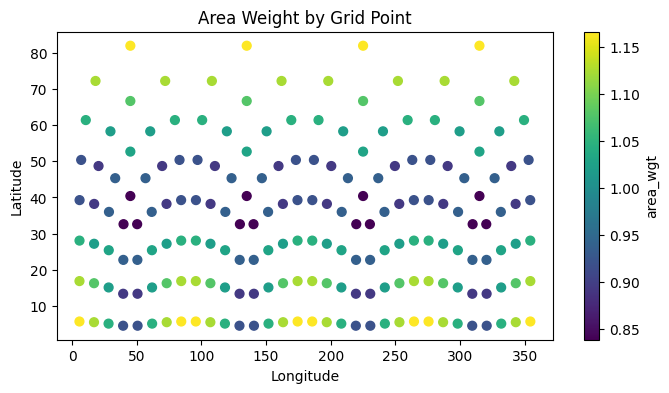

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.scatter(lon, lat, c=area_wgt, s=40)
plt.colorbar(label='area_wgt')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Area Weight by Grid Point")
plt.show()

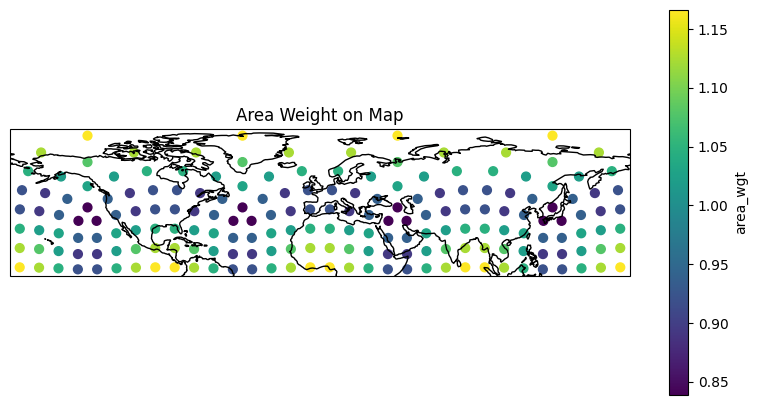

In [41]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

plt.figure(figsize=(10,5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
sc = ax.scatter(lon, lat, c=area_wgt, s=40, transform=ccrs.PlateCarree())
plt.colorbar(sc, label='area_wgt')
plt.title("Area Weight on Map")
plt.show()

In [42]:
unscaled_ds

<xarray.Dataset> Size: 3MB
Dimensions:      (sample: 20, ncol: 192, lev: 45)
Coordinates:
  * sample       (sample) int64 160B 0 1 2 3 4 5 6 7 ... 12 13 14 15 16 17 18 19
  * ncol         (ncol) int64 2kB 0 1 2 3 4 5 6 ... 185 186 187 188 189 190 191
  * lev          (lev) int64 360B 0 1 2 3 4 5 6 7 8 ... 37 38 39 40 41 42 43 44
Data variables:
    ptend_t      (sample, ncol, lev) float64 1MB 1.463e-05 ... -0.01732
    ptend_q0001  (sample, ncol, lev) float64 1MB 8.979e-09 ... 6.689e-06
    netsw        (sample, ncol) float64 31kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    flwds        (sample, ncol) float64 31kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    precsc       (sample, ncol) float64 31kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    precc        (sample, ncol) float64 31kB 3.219e-08 3.22e-08 ... 3.277e-08
    sols         (sample, ncol) float64 31kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    soll         (sample, ncol) float64 31kB 16.79 16.83 16.79 ... 17.01 16.9
    solsd        (sample, ncol) float64 31kB 4.396 4.376 4.386 ... 4.418 4.42
    solld        (sample, ncol) float64 31kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

In [45]:
weighted_ds = unscaled_ds * area_wgt

print(unscaled_ds['ptend_q0001'][0, 10, 0].values)
print(weighted_ds['ptend_q0001'][0,10,0].values)
# 1.4474995728689308e-05
# 1.6257417038797464e-05
weighted_ds

9.051596038124544e-09
1.0166191024627152e-08


<xarray.Dataset> Size: 3MB
Dimensions:      (sample: 20, ncol: 192, lev: 45)
Coordinates:
  * sample       (sample) int64 160B 0 1 2 3 4 5 6 7 ... 12 13 14 15 16 17 18 19
  * ncol         (ncol) int64 2kB 0 1 2 3 4 5 6 ... 185 186 187 188 189 190 191
  * lev          (lev) int64 360B 0 1 2 3 4 5 6 7 8 ... 37 38 39 40 41 42 43 44
Data variables:
    ptend_t      (sample, ncol, lev) float64 1MB 1.347e-05 ... -0.01453
    ptend_q0001  (sample, ncol, lev) float64 1MB 8.267e-09 ... 5.61e-06
    netsw        (sample, ncol) float64 31kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    flwds        (sample, ncol) float64 31kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    precsc       (sample, ncol) float64 31kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    precc        (sample, ncol) float64 31kB 2.964e-08 3.371e-08 ... 2.748e-08
    sols         (sample, ncol) float64 31kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    soll         (sample, ncol) float64 31kB 15.46 17.62 14.99 ... 15.96 14.18
    solsd        (sample, ncol) float64 31kB 4.048 4.582 3.915 ... 4.145 3.707
    solld        (sample, ncol) float64 31kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

### Unit conversion

In [47]:
cp = 1.00464e3  # specific heat of dry air   ~ J/kg/K
lv = 2.501e6    # latent heat of evaporation ~ J/kg
rho_h20 = 1.e3       # density of fresh water     ~ kg/m^ 3


target_energy_conv = xr.Dataset(data_vars = {'ptend_t':cp,
                                   'ptend_q0001':lv,
                                   'ptend_q0002':lv,
                                   'ptend_q0003':lv,
                                   'ptend_qn':lv,
                                   'ptend_wind': None,
                                   'cam_out_NETSW':1.,
                                   'cam_out_FLWDS':1.,
                                   'cam_out_PRECSC':lv*rho_h20,
                                   'cam_out_PRECC':lv*rho_h20,
                                   'cam_out_SOLS':1.,
                                   'cam_out_SOLL':1.,
                                   'cam_out_SOLSD':1.,
                                   'cam_out_SOLLD':1.
                                  })
target_energy_conv = target_energy_conv[list(cfg.dataset.v1_targets)]
target_energy_conv = target_energy_conv.rename(rename_dict)

In [48]:
unit_converted = weighted_ds * target_energy_conv

unit_converted

<xarray.Dataset> Size: 3MB
Dimensions:      (sample: 20, ncol: 192, lev: 45)
Coordinates:
  * sample       (sample) int64 160B 0 1 2 3 4 5 6 7 ... 12 13 14 15 16 17 18 19
  * ncol         (ncol) int64 2kB 0 1 2 3 4 5 6 ... 185 186 187 188 189 190 191
  * lev          (lev) int64 360B 0 1 2 3 4 5 6 7 8 ... 37 38 39 40 41 42 43 44
Data variables:
    ptend_t      (sample, ncol, lev) float64 1MB 0.01353 -0.03117 ... -14.6
    ptend_q0001  (sample, ncol, lev) float64 1MB 0.02068 0.03124 ... 14.33 14.03
    netsw        (sample, ncol) float64 31kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    flwds        (sample, ncol) float64 31kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    precsc       (sample, ncol) float64 31kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    precc        (sample, ncol) float64 31kB 74.13 84.31 72.23 ... 77.0 68.73
    sols         (sample, ncol) float64 31kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    soll         (sample, ncol) float64 31kB 15.46 17.62 14.99 ... 15.96 14.18
    solsd        (sample, ncol) float64 31kB 4.048 4.582 3.915 ... 4.145 3.707
    solld        (sample, ncol) float64 31kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

In [52]:
print(weighted_ds['ptend_t'][0,0,5].values)
print(target_energy_conv['ptend_t'].values)
print(unit_converted['ptend_t'][0,0,5].values)

-0.00022647673348804225
1004.64
-0.22752758553142677


In [55]:
print(weighted_ds['soll'][0,5].values)
print(target_energy_conv['soll'].values)
print(unit_converted['soll'][0,5].values)

19.604120297849022
1.0
19.604120297849022


Great that should be all the processing - now we can apply the metrics and then plot the results.

# Calculating the metrics 
Very basically, we need to 

1. get both target and true $y$ in the correct format (aka the above pipeline)

2. Iterate through each variable 

3. Iterate through each metric 

4. calculate the metric 

5. store the results 

I think we can do this in xarray stuff 

In [9]:
from evaluate import OutputWeighting

In [10]:
output_weighting = OutputWeighting(cfg=cfg)

In [11]:
weighted_pred_ds = output_weighting.weight(preds, testset)
weighted_target_ds = output_weighting.weight(targets, testset)

In [15]:
weighted_pred_ds

<xarray.Dataset> Size: 3MB
Dimensions:      (sample: 20, ncol: 192, lev: 45)
Coordinates:
  * sample       (sample) int64 160B 0 1 2 3 4 5 6 7 ... 12 13 14 15 16 17 18 19
  * ncol         (ncol) int64 2kB 0 1 2 3 4 5 6 ... 185 186 187 188 189 190 191
  * lev          (lev) int64 360B 0 1 2 3 4 5 6 7 8 ... 37 38 39 40 41 42 43 44
Data variables:
    ptend_t      (sample, ncol, lev) float64 1MB 0.01353 -0.03117 ... -14.6
    ptend_q0001  (sample, ncol, lev) float64 1MB 0.02068 0.03124 ... 14.33 14.03
    netsw        (sample, ncol) float64 31kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    flwds        (sample, ncol) float64 31kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    precsc       (sample, ncol) float64 31kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    precc        (sample, ncol) float64 31kB 74.13 84.31 72.23 ... 77.0 68.73
    sols         (sample, ncol) float64 31kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    soll         (sample, ncol) float64 31kB 15.46 17.62 14.99 ... 15.96 14.18
    solsd        (sample, ncol) float64 31kB 4.048 4.582 3.915 ... 4.145 3.707
    solld        (sample, ncol) float64 31kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

In [13]:
weighted_target_ds

<xarray.Dataset> Size: 3MB
Dimensions:      (sample: 20, ncol: 192, lev: 45)
Coordinates:
  * sample       (sample) int64 160B 0 1 2 3 4 5 6 7 ... 12 13 14 15 16 17 18 19
  * ncol         (ncol) int64 2kB 0 1 2 3 4 5 6 ... 185 186 187 188 189 190 191
  * lev          (lev) int64 360B 0 1 2 3 4 5 6 7 8 ... 37 38 39 40 41 42 43 44
Data variables:
    ptend_t      (sample, ncol, lev) float64 1MB -0.004716 -0.01675 ... 10.1
    ptend_q0001  (sample, ncol, lev) float64 1MB -1.501e-07 2.499e-06 ... 6.814
    netsw        (sample, ncol) float64 31kB 0.0 0.0 0.0 0.0 ... 0.0 7.739 0.0
    flwds        (sample, ncol) float64 31kB 399.9 453.0 377.7 ... 253.3 301.3
    precsc       (sample, ncol) float64 31kB 0.0 0.0 0.0 ... 30.49 4.202 6.559
    precc        (sample, ncol) float64 31kB 11.04 160.3 1.656 ... 8.241 265.7
    sols         (sample, ncol) float64 31kB 0.0 0.0 0.0 0.0 ... 0.0 0.3183 0.0
    soll         (sample, ncol) float64 31kB 0.0 0.0 0.0 0.0 ... 0.0 3.293 0.0
    solsd        (sample, ncol) float64 31kB 0.0 0.0 0.0 0.0 ... 0.0 3.566 0.0
    solld        (sample, ncol) float64 31kB 0.0 0.0 0.0 0.0 ... 0.0 2.319 0.0

Time to define the metrics ...

In [33]:
class MetricsCalculator:
    def __init__(self, num_latlon):
        self.num_latlon = num_latlon

        self.metrics_dict = {'MAE': self.calc_MAE,
            'RMSE': self.calc_RMSE,
            'R2': self.calc_R2,
            # 'CRPS': self.calc_CRPS,
            'bias': self.calc_bias
        }

    def calc_MAE(self, pred, target, avg_grid = True):
        '''
        calculate 'globally averaged' mean absolute error 
        for vertically-resolved variables, shape should be time x grid x level
        for scalars, shape should be time x grid

        returns vector of length level or 1
        '''
        assert pred.shape[1] == self.num_latlon
        assert pred.shape == target.shape
        mae = np.abs(pred - target).mean(axis = 0)
        if avg_grid:
            return mae.mean(axis = 0) # we decided to average globally at end
        else:
            return mae
        
    def calc_RMSE(self, pred, target, avg_grid = True):
        '''
        calculate 'globally averaged' root mean squared error 
        for vertically-resolved variables, shape should be time x grid x level
        for scalars, shape should be time x grid

        returns vector of length level or 1
        '''
        assert pred.shape[1] == self.num_latlon
        assert pred.shape == target.shape
        sq_diff = (pred - target)**2
        rmse = np.sqrt(sq_diff.mean(axis = 0)) # mean over time
        if avg_grid:
            return rmse.mean(axis = 0) # we decided to separately average globally at end
        else:
            return rmse

    def calc_R2(self, pred, target, avg_grid = True):
        '''
        calculate 'globally averaged' R-squared
        for vertically-resolved variables, input shape should be time x grid x level
        for scalars, input shape should be time x grid

        returns vector of length level or 1
        '''
        assert pred.shape[1] == self.num_latlon
        assert pred.shape == target.shape
        sq_diff = (pred - target)**2
        tss_time = (target - target.mean(axis = 0)[np.newaxis, ...])**2 # mean over time
        r_squared = 1 - sq_diff.sum(axis = 0)/tss_time.sum(axis = 0) # sum over time
        if avg_grid:
            return r_squared.mean(axis = 0) # we decided to separately average globally at end
        else:
            return r_squared
        
    def calc_bias(self, pred, target, avg_grid = True):
        '''
        calculate bias
        for vertically-resolved variables, input shape should be time x grid x level
        for scalars, input shape should be time x grid
        returns vector of length level or 1
        '''
        assert pred.shape[1] == self.num_latlon
        assert pred.shape == target.shape
        bias = pred.mean(axis = 0) - target.mean(axis = 0)
        if avg_grid:
            return bias.mean(axis = 0) # we decided to separately average globally at end
        else:
            return bias
        
    def calc_CRPS(self, samplepreds, target, avg_grid = True):
        '''
        calculate 'globally averaged' continuous ranked probability score
        for vertically-resolved variables, input shape should be time x grid x level x num_crps_samples
        for scalars, input shape should be time x grid x num_crps_samples
        returns vector of length level or 1
        '''
        assert samplepreds.shape[1] == self.num_latlon
        assert len(samplepreds.shape) == len(target.shape) + 1
        assert len(samplepreds.shape) == 3 or len(samplepreds.shape) == 4
        num_crps = samplepreds.shape[-1]
        mae = np.mean(np.abs(samplepreds - target[..., np.newaxis]), axis = (0, -1)) # mean over time and crps samples
        samplepreds = np.sort(samplepreds, axis = -1)
        diff = samplepreds[..., 1:] - samplepreds[..., :-1]
        count = np.arange(1, num_crps) * np.arange(num_crps - 1, 0, -1)
        if len(samplepreds.shape) == 4:
            spread = (diff * count[np.newaxis, np.newaxis, np.newaxis, :]).sum(axis = -1).mean(axis = 0) # sum over crps samples and mean over time
        elif len(samplepreds.shape) == 3:
            spread = (diff * count[np.newaxis, np.newaxis, :]).sum(axis = -1).mean(axis = 0) # sum over crps samples and mean over time
        crps = mae - spread/(num_crps*(num_crps-1))
        # count was not multiplied by two so no need to divide by two
        if avg_grid:
            return crps.mean(axis = 0) # we decided to separately average globally at end
        else:
            return crps

In [34]:
metrics_calculator = MetricsCalculator(num_latlon=192)

In [36]:

results = {}
for metric_name, metric_func in metrics_calculator.metrics_dict.items():
    print(f"Calculating {metric_name}...")
    results[metric_name] = {}
    for var in weighted_pred_ds.data_vars:
        # print(f"  Variable: {var}")
        pred = weighted_pred_ds[var].values
        target = weighted_target_ds[var].values

        metric_result = metric_func(pred, target)

        results[metric_name][var] = metric_result
        print(f"{metric_name} for {var}: {metric_result.mean():.2f}")

Calculating MAE...
MAE for ptend_t: 9.86
MAE for ptend_q0001: 14.49
MAE for netsw: 131.29
MAE for flwds: 365.10
MAE for precsc: 5.84
MAE for precc: 116.54
MAE for sols: 50.53
MAE for soll: 59.21
MAE for solsd: 28.36
MAE for solld: 14.44
Calculating RMSE...
RMSE for ptend_t: 11.52
RMSE for ptend_q0001: 18.86
RMSE for netsw: 231.72
RMSE for flwds: 366.50
RMSE for precsc: 8.61
RMSE for precc: 177.15
RMSE for sols: 97.61
RMSE for soll: 97.95
RMSE for solsd: 44.54
RMSE for solld: 27.12
Calculating R2...
R2 for ptend_t: -36.15
R2 for ptend_q0001: -2496672183.51
R2 for netsw: -0.44
R2 for flwds: -708.77
R2 for precsc: nan
R2 for precc: -inf
R2 for sols: -0.33
R2 for soll: -6.41
R2 for solsd: -0.37
R2 for solld: -0.40
Calculating bias...
bias for ptend_t: -3.38
bias for ptend_q0001: 4.09
bias for netsw: -131.29
bias for flwds: -365.10
bias for precsc: -5.84
bias for precc: -9.81
bias for sols: -50.53
bias for soll: -37.17
bias for solsd: -23.49
bias for solld: -14.44


/tmp/ipykernel_1761054/1938093102.py:57: RuntimeWarning: invalid value encountered in divide
  r_squared = 1 - sq_diff.sum(axis = 0)/tss_time.sum(axis = 0) # sum over time
/tmp/ipykernel_1761054/1938093102.py:57: RuntimeWarning: divide by zero encountered in divide
  r_squared = 1 - sq_diff.sum(axis = 0)/tss_time.sum(axis = 0) # sum over time


Nice! Now I just need to plot the results 

In [37]:
print(len(results))

4


/home/users/bradlesc/projects/ClimSim/.venv/lib/python3.12/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


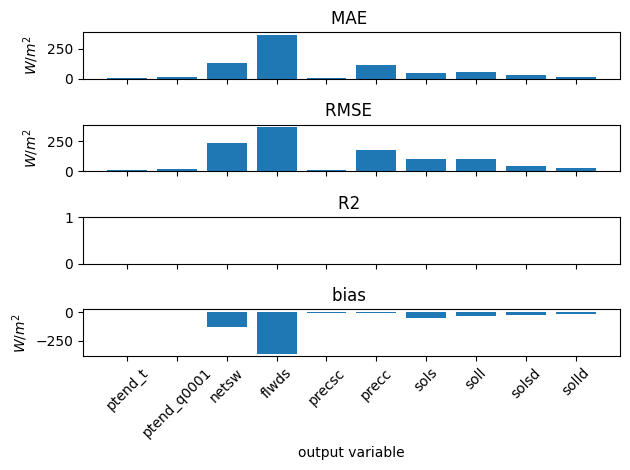

In [42]:
import matplotlib.pyplot as plt


fix, axes = plt.subplots(nrows=len(results), sharex=True)
for ax, (metric_name, metric_values) in zip(axes, results.items()):
    vars = list(metric_values.keys())
    values = [metric_values[var].mean() for var in vars]
    ax.bar(vars, values)
    ax.set_ylabel('$W/m^2$') if metric_name != "R2" else ax.set_ylim(0, 1)
    ax.set_title(f"{metric_name} ")
    ax.tick_params(axis='x', rotation=45)
axes[-1].set_xlabel("output variable")
plt.tight_layout()
plt.show()

/home/users/bradlesc/projects/ClimSim/.venv/lib/python3.12/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
/home/users/bradlesc/projects/ClimSim/.venv/lib/python3.12/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


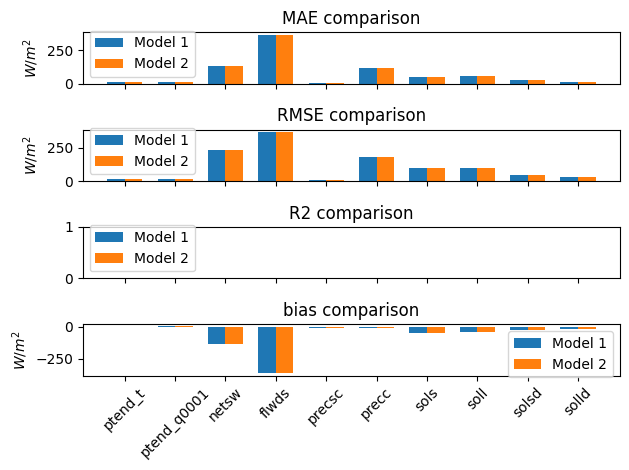

In [ ]:
model1_results = results
model2_results = results

plot_df_byvar = {}

for metric_name in model1_results.keys():
    plot_df_byvar[metric_name] = pd.DataFrame({



fig, axes = plt.subplots(nrows=len(model1_results), sharex=True)
for ax, metric_name in zip(axes, model1_results.keys()):
    vars = list(model1_results[metric_name].keys())
    model1_values = [model1_results[metric_name][var].mean() for var in vars]
    model2_values = [model2_results[metric_name][var].mean() for var in vars]
    
    x = np.arange(len(vars))
    width = 0.35
    
    ax.bar(x - width/2, model1_values, width, label='Model 1')
    ax.bar(x + width/2, model2_values, width, label='Model 2')
    
    ax.set_ylabel('$W/m^2$') if metric_name != "R2" else ax.set_ylim(0, 1)
    ax.set_title(f"{metric_name} comparison")
    ax.set_xticks(x)
    ax.set_xticklabels(vars, rotation=45)
    ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import chain

def plot_model_comparisons(models_dict, figsize_per_row=(6, 3), cmap_name='tab10'):
    """
    Plot grouped bar charts for metrics across an arbitrary number of models.

    Parameters
    ----------
    models_dict : dict
        Mapping model_name -> results, where results is mapping:
            metric_name -> { var_name: array_like, ... }
    figsize_per_row : tuple
        Width, height per subplot row (will be multiplied by number of metrics).
    cmap_name : str
        Matplotlib colormap name to choose distinct colors for models.
    """
    # Collect metric names (union across models)
    metric_names = sorted(set(chain.from_iterable(m.keys() for m in models_dict.values())))

    # Prepare figure
    nrows = len(metric_names)
    figsize = (figsize_per_row[0], figsize_per_row[1] * nrows)
    fig, axes = plt.subplots(nrows=nrows, figsize=figsize, sharex=False)
    axes = np.atleast_1d(axes)  # handle single-row case

    model_names = list(models_dict.keys())
    n_models = len(model_names)

    # colors
    cmap = plt.get_cmap(cmap_name)
    colors = [cmap(i % cmap.N) for i in range(n_models)]

    for ax, metric in zip(axes, metric_names):
        # build ordered list of vars: start from first model encountered, then add any missing
        first_model = model_names[0]
        vars_order = []
        # gather union but try to preserve order from first model
        if metric in models_dict[first_model]:
            vars_order.extend(models_dict[first_model][metric].keys())
        # add any variables present in other models
        for m in model_names:
            if metric in models_dict[m]:
                for v in models_dict[m][metric].keys():
                    if v not in vars_order:
                        vars_order.append(v)
        if not vars_order:
            # nothing to plot for this metric
            ax.text(0.5, 0.5, f'No data for metric "{metric}"', ha='center', va='center')
            ax.set_axis_off()
            continue

        x = np.arange(len(vars_order))

        # width per bar group scaled by number of models
        total_group_width = 0.8
        single_width = total_group_width / n_models
        offsets = (np.arange(n_models) - (n_models-1)/2) * single_width

        # For each model, compute means for each var (nan if missing)
        for i, model in enumerate(model_names):
            values = []
            for v in vars_order:
                try:
                    val = models_dict[model][metric][v]
                    # attempt to compute mean; if scalar-like, cast to float
                    mean_val = np.asarray(val).mean().item()
                except Exception:
                    mean_val = np.nan
                values.append(mean_val)
            ax.bar(x + offsets[i], values, single_width, label=model, color=colors[i], edgecolor='k', linewidth=0.3)

        # axis labels / formatting
        if metric.lower() == "r2":
            ax.set_ylim(0, 1)
            ax.set_ylabel("R2")
        else:
            ax.set_ylabel("$W/m^2$")

        ax.set_title(f"{metric}")
        ax.set_xticks(x)
        ax.set_xticklabels(vars_order, rotation=45, ha='right')
        ax.legend()
        ax.grid(axis='y', linestyle=':', alpha=0.5)
    axes[-1].set_xlabel("Output variables")

    plt.tight_layout()
    plt.show()




/home/users/bradlesc/projects/ClimSim/.venv/lib/python3.12/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
/home/users/bradlesc/projects/ClimSim/.venv/lib/python3.12/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


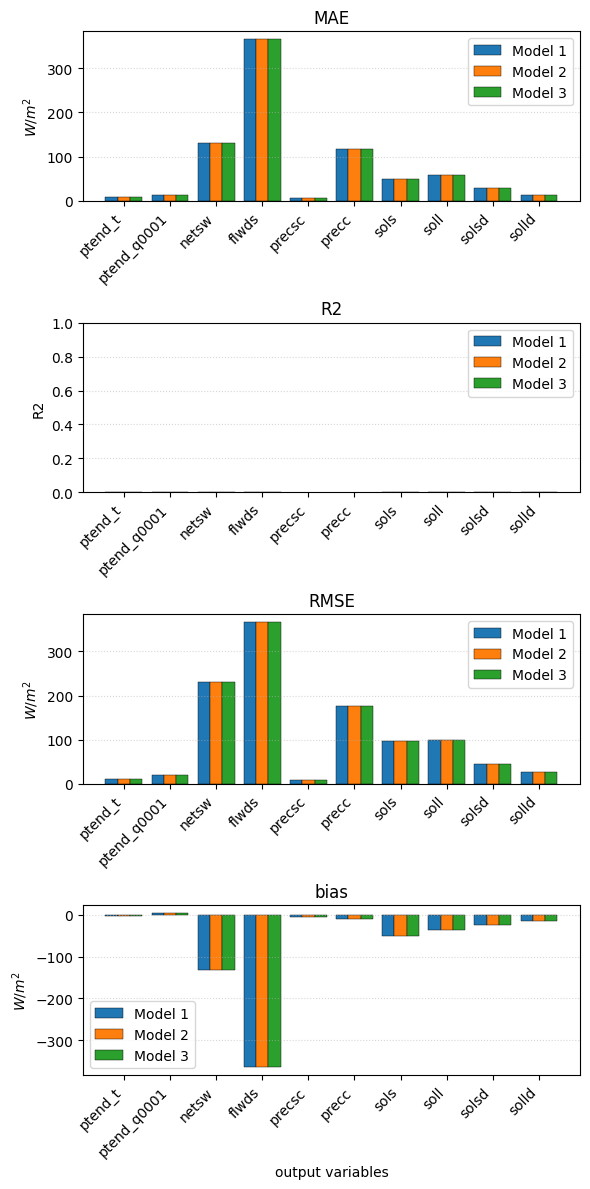

In [54]:

model1_results = results
model2_results = results
model3_results = results
models = {"Model 1": model1_results, "Model 2": model2_results, "Model 3": model3_results}
plot_model_comparisons(models)
